# **LEVEL 1**

# **Task1(Data Preprocessing)**

# **Import Libaries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

# **Load Dataset**

In [2]:
df=pd.read_csv("/kaggle/input/datasets/junaeidali123/stock-price-dataset/2) Stock Prices Data Set.csv")

## Preview Dataset



In [3]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


## Dataset Info



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


# **Check Missing Values**

In [5]:
print(df.isnull().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


# **Fill Numerical Columns**

In [6]:
numerical_cols = ['open', 'high', 'low', 'close', 'volume']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())


# **Apply Label Encoder on Categorical Column**

In [7]:
from sklearn.preprocessing import LabelEncoder

## Encode Stock Symbol



In [8]:
label_encoder = LabelEncoder()

df['symbol_encoded'] = label_encoder.fit_transform(df['symbol'])

df.drop('symbol', axis=1, inplace=True)

# **Split or Convert Date Column into (year, Month,Date)**

In [9]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df.drop('date', axis=1, inplace=True)


## Inspect Engineered Dataset



In [10]:
df

,open,high,low,close,volume,symbol_encoded,year,month,day
0,25.0700,25.8200,25.0600,25.3600,8998943,1,2014,1,2
1,79.3828,79.5756,78.8601,79.0185,58791957,3,2014,1,2
2,110.3600,111.8800,109.2900,109.7400,542711,2,2014,1,2
3,52.1200,52.3300,51.5200,51.9800,4569061,4,2014,1,2
4,70.1100,70.2300,69.4800,69.8900,1148391,5,2014,1,2
...,...,...,...,...,...,...,...,...,...
497467,68.5300,68.8000,67.9200,68.2000,1046677,500,2017,12,29
497468,82.6400,82.7100,81.5900,81.6100,1347613,501,2017,12,29
497469,121.7500,121.9500,120.6200,120.6700,1023624,502,2017,12,29
497470,51.2800,51.5500,50.8100,50.8300,1261916,503,2017,12,29


# **Train_Test Split**



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Perform Train/Test Split



In [12]:
X = df.drop('close', axis=1)
y = df['close']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Apply Standard Scaler**



In [13]:
scaler = StandardScaler()

feature_cols = ['open', 'high', 'low', 'volume']

X_train[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_test[feature_cols]  = scaler.transform(X_test[feature_cols])

df[feature_cols] = scaler.transform(df[feature_cols])

# **Display**

In [14]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nProcessed Dataset:")
print(df.head())

Training Features Shape: (397977, 8)
Testing Features Shape: (99495, 8)

Processed Dataset:
       open      high       low     close    volume  symbol_encoded  year  \
0 -0.604445 -0.599756 -0.601940   25.3600  0.581024               1  2014   
1 -0.068684 -0.073861 -0.066544   79.0185  6.661927               3  2014   
2  0.236886  0.242175  0.236282  109.7400 -0.451682               2  2014   
3 -0.337614 -0.340407 -0.338621   51.9800  0.040030               4  2014   
4 -0.160154 -0.165290 -0.159891   69.8900 -0.377714               5  2014   

   month  day  
0      1    2  
1      1    2  
2      1    2  
3      1    2  
4      1    2  


# **Task 2 (Linear Regression Model)**

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

## Generate Predictions



In [16]:
y_pred = lr_model.predict(X_test)

## Model Coefficients



In [17]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})

print(coefficients)

          Feature  Coefficient
0            open   -54.150789
1            high    79.615768
2             low    75.915890
3          volume    -0.000793
4  symbol_encoded    -0.000004
5            year     0.003570
6           month    -0.003914
7             day    -0.001792


## Evaluation Metrics — R² and MSE



In [18]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error (MSE):", mse)

R-squared: 0.9999491353703018
Mean Squared Error (MSE): 0.5273084619842326


## Evaluation Metric — RMSE



In [19]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.7261600801367648


# **LEVEL 2**

# **Task 2(Decession Tree)**

In [20]:


median_close = df['close'].median()

df['price_class'] = np.where(
    df['close'] >= median_close,
    'High',
    'Low'
)

## Import Decision Tree Libraries



In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

## Redefine Features and Target for Classification



In [22]:
X = df.drop(['close', 'price_class'], axis=1)
y = df['price_class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train Full Decision Tree



In [23]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

## Evaluate Full Decision Tree



In [24]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='High')

print("Accuracy:", acc)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9967435549525102
F1 Score: 0.996745027124774

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     49755
         Low       1.00      1.00      1.00     49740

    accuracy                           1.00     99495
   macro avg       1.00      1.00      1.00     99495
weighted avg       1.00      1.00      1.00     99495



## Visualize Full Decision Tree



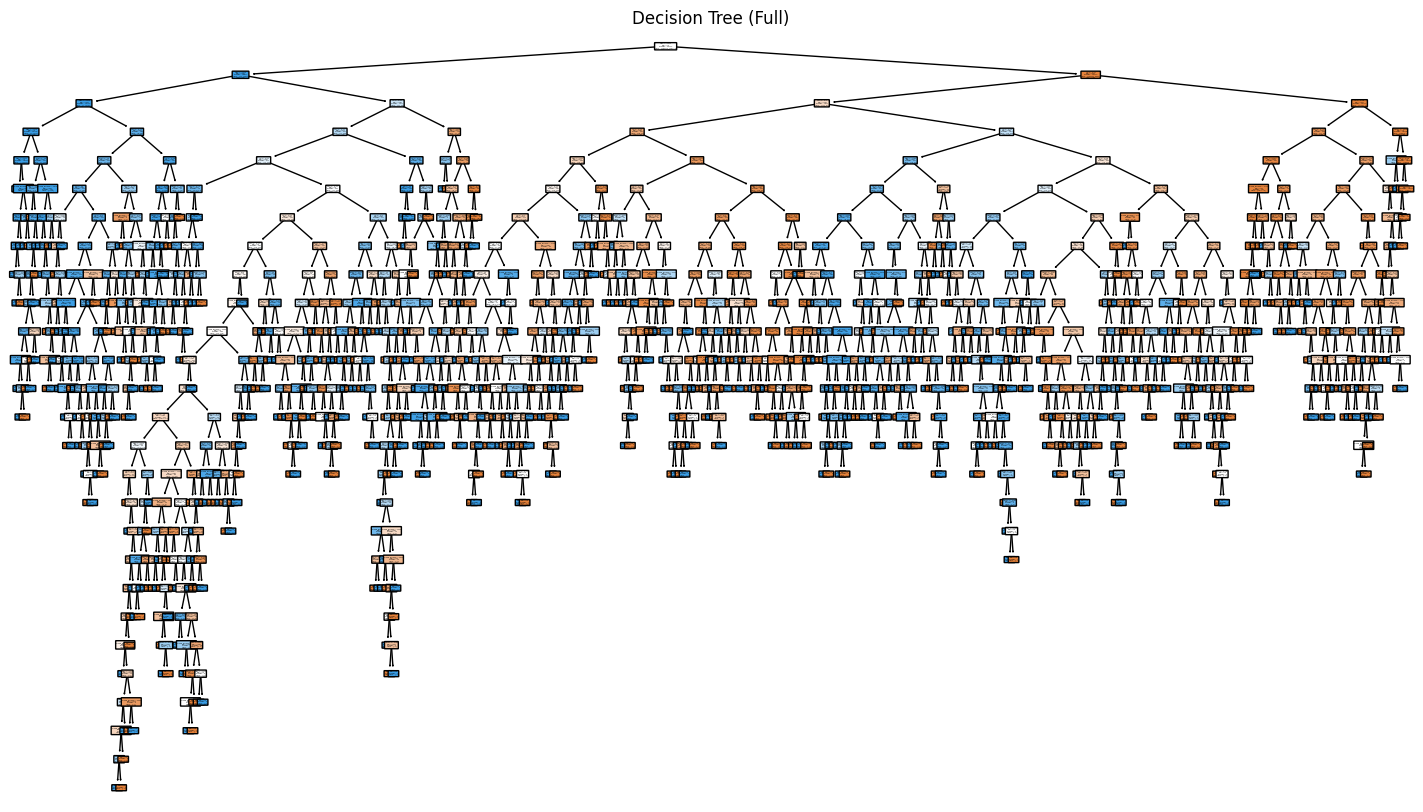

In [25]:
plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree (Full)")
plt.show()

## Train Pruned Decision Tree



In [26]:
pruned_dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

pruned_dt.fit(X_train, y_train)

y_pred_pruned = pruned_dt.predict(X_test)

## Evaluate Pruned Decision Tree



In [27]:
acc_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, pos_label='High')

print("Pruned Accuracy:", acc_pruned)
print("Pruned F1 Score:", f1_pruned)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned))

Pruned Accuracy: 0.9972058897432031
Pruned F1 Score: 0.9972081065338342

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     49755
         Low       1.00      1.00      1.00     49740

    accuracy                           1.00     99495
   macro avg       1.00      1.00      1.00     99495
weighted avg       1.00      1.00      1.00     99495



## Visualize Pruned Decision Tree



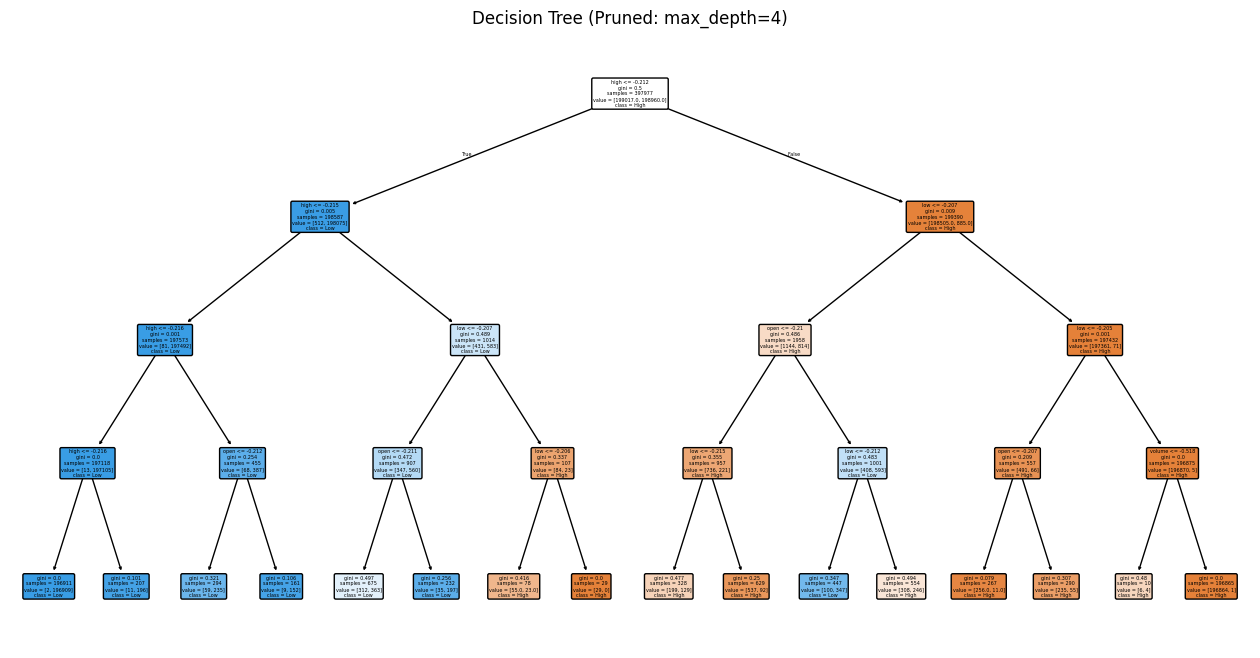

In [28]:
plt.figure(figsize=(16,8))

plot_tree(
    pruned_dt,
    feature_names=X.columns,
    class_names=pruned_dt.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree (Pruned: max_depth=4)")
plt.show()

# **Task 3: K-Means Clustering**

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Select Clustering Features



In [30]:
cluster_features = [
    'open',
    'high',
    'low',
    'volume'
]

X_cluster = df[cluster_features]

## Prepare Scaled Feature Array



In [31]:
X_scaled = X_cluster.values

## Elbow Method — Compute Inertia



In [32]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

## Elbow Method — Plot



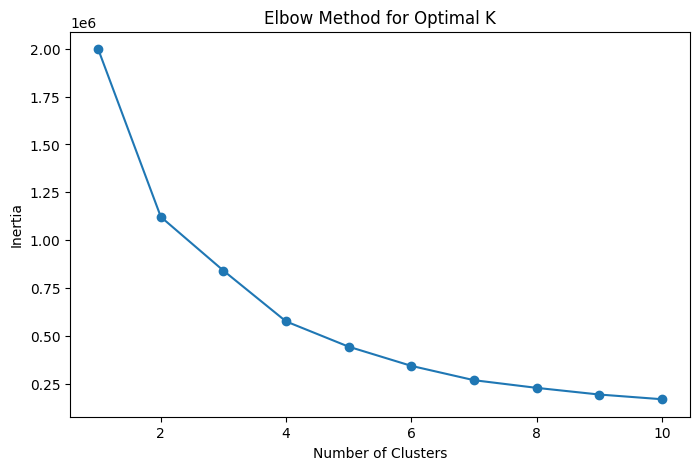

In [33]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

## Fit Final KMeans Model (K=4)



In [34]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

## Visualize Clusters (Open vs Close Price)



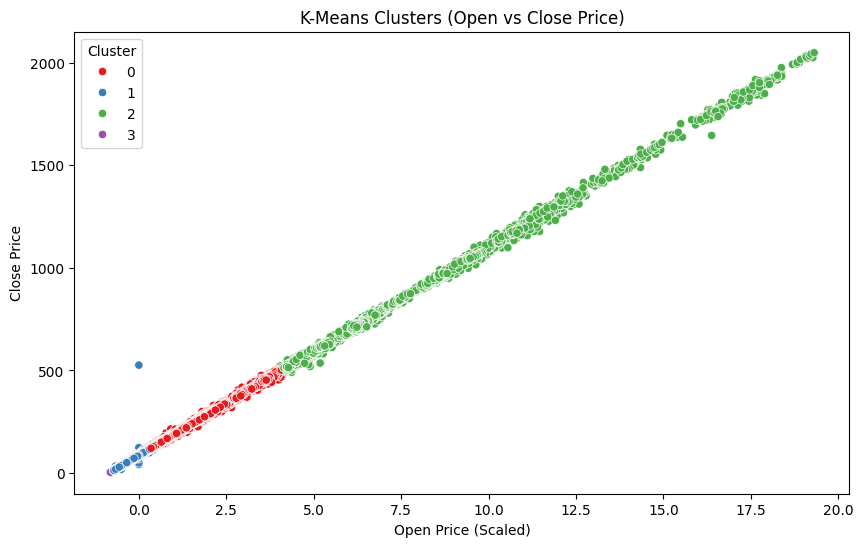

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['open'],
    y=df['close'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("K-Means Clusters (Open vs Close Price)")
plt.xlabel("Open Price (Scaled)")
plt.ylabel("Close Price")
plt.show()

## Cluster Summary Statistics



In [36]:
cluster_summary = df.groupby('Cluster')[
    ['open','high','low','close','volume']
].mean()

print("Cluster Mean Values:")
print(cluster_summary)

Cluster Mean Values:
             open      high       low       close    volume
Cluster                                                    
0        0.925456  0.926038  0.925019  180.192415 -0.335212
1       -0.259610 -0.259727 -0.259474   60.044928 -0.069558
2        7.290367  7.288880  7.289108  825.303873 -0.346680
3       -0.484408 -0.483392 -0.485990   37.218739  4.688131


# **LEVEL 3**

# **Task1: Random Forest Classifier**

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

## Cross-Validation



In [38]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.99602995 0.99643198 0.99653245 0.9976883  0.99679378]

Mean CV Accuracy:
0.9966952932600301


## Evaluate Random Forest on Test Set



In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_rf = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(
          y_test,
          y_pred_rf,
          pos_label='High'
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_rf,
          pos_label='High'
      ))

print("F1 Score:",
      f1_score(
          y_test,
          y_pred_rf,
          pos_label='High'
      ))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.997517463189105
Precision: 0.9971681060453906
Recall: 0.9978695608481559
F1 Score: 0.9975187101310965

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     49755
         Low       1.00      1.00      1.00     49740

    accuracy                           1.00     99495
   macro avg       1.00      1.00      1.00     99495
weighted avg       1.00      1.00      1.00     99495



## Feature Importance Table



In [40]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

          Feature  Importance
1            high    0.430153
2             low    0.340471
0            open    0.212299
3          volume    0.013937
4  symbol_encoded    0.001889
5            year    0.000584
7             day    0.000381
6           month    0.000286


## Feature Importance Bar Chart



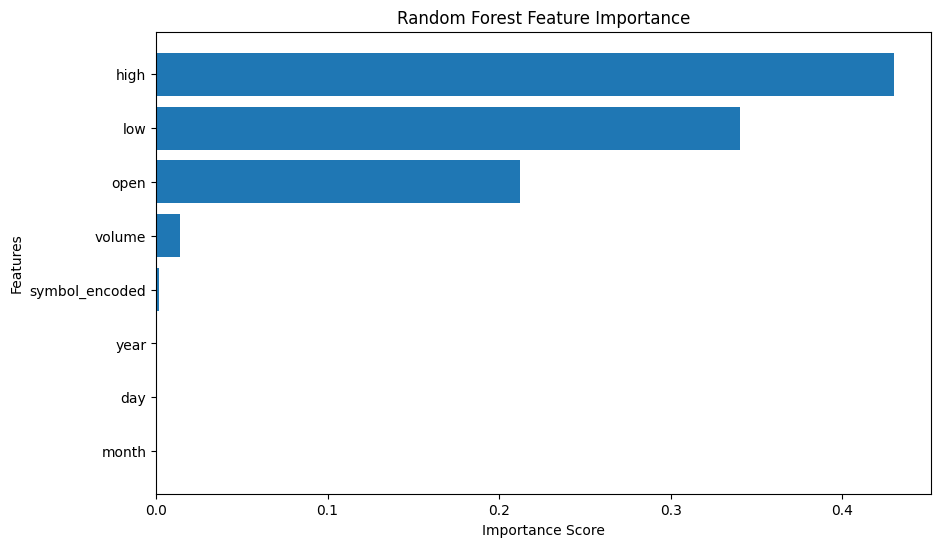

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## Top 5 Most Important Features



In [42]:
print("Top 5 Important Features:\n")

print(feature_importance.head())

Top 5 Important Features:

          Feature  Importance
1            high    0.430153
2             low    0.340471
0            open    0.212299
3          volume    0.013937
4  symbol_encoded    0.001889


# **Task 2: Support Vector Machine (SVM)**

## Imports



In [43]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Sampling for SVM Training



In [44]:
SAMPLE_SIZE = min(5000, len(X_train))

from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=SAMPLE_SIZE, random_state=42)
train_idx, _ = next(sss.split(X_train, y_train))

X_train_svm = X_train.iloc[train_idx].reset_index(drop=True)
y_train_svm = y_train.iloc[train_idx].reset_index(drop=True)

print(f"SVM training on {SAMPLE_SIZE} samples (stratified subset of {len(X_train)} total training rows)")
print("Class distribution in SVM sample:")
print(y_train_svm.value_counts())

SVM training on 5000 samples (stratified subset of 397977 total training rows)
Class distribution in SVM sample:
price_class
High    2500
Low     2500
Name: count, dtype: int64


## Train Linear SVM

In [45]:
svm_linear = SVC(
    kernel='linear',
    random_state=42,
    probability=True  
)

svm_linear.fit(X_train_svm, y_train_svm)

linear_pred = svm_linear.predict(X_test)

print("Linear SVM training complete.")

Linear SVM training complete.


## Train RBF SVM

In [46]:
svm_rbf = SVC(
    kernel='rbf',
    gamma='scale',
    random_state=42,
    probability=True 
)

svm_rbf.fit(X_train_svm, y_train_svm)

rbf_pred = svm_rbf.predict(X_test)

print("RBF SVM training complete.")

RBF SVM training complete.


## Encode Labels for AUC Calculation



In [47]:
label_encoder = LabelEncoder()

label_encoder.fit(['High', 'Low'])

y_test_encoded = label_encoder.transform(y_test)

print("Label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label encoding: {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1)}


## Linear SVM Results

In [48]:
linear_proba = svm_linear.predict_proba(X_test)[:, 1]

print("LINEAR SVM RESULTS")
print("-" * 40)

print("Accuracy:",
      accuracy_score(y_test, linear_pred))

print("Precision:",
      precision_score(
          y_test,
          linear_pred,
          pos_label='High'
      ))

print("Recall:",
      recall_score(
          y_test,
          linear_pred,
          pos_label='High'
      ))

print("F1 Score:",
      f1_score(
          y_test,
          linear_pred,
          pos_label='High'
      ))

print("AUC:",
      roc_auc_score(
          y_test_encoded,
          linear_proba
      ))

print("\nClassification Report")
print(classification_report(y_test, linear_pred))

LINEAR SVM RESULTS
----------------------------------------
Accuracy: 0.9770239710538218
Precision: 0.9621653198325382
Recall: 0.9931062204803537
F1 Score: 0.9773909603402235
AUC: 0.9989265396017487

Classification Report
              precision    recall  f1-score   support

        High       0.96      0.99      0.98     49755
         Low       0.99      0.96      0.98     49740

    accuracy                           0.98     99495
   macro avg       0.98      0.98      0.98     99495
weighted avg       0.98      0.98      0.98     99495



## RBF SVM Results

In [49]:
rbf_proba = svm_rbf.predict_proba(X_test)[:, 1]

print("RBF SVM RESULTS")
print("-" * 40)

print("Accuracy:",
      accuracy_score(y_test, rbf_pred))

print("Precision:",
      precision_score(
          y_test,
          rbf_pred,
          pos_label='High'
      ))

print("Recall:",
      recall_score(
          y_test,
          rbf_pred,
          pos_label='High'
      ))

print("F1 Score:",
      f1_score(
          y_test,
          rbf_pred,
          pos_label='High'
      ))

print("AUC:",
      roc_auc_score(
          y_test_encoded,
          rbf_proba
      ))

print("\nClassification Report")
print(classification_report(y_test, rbf_pred))

RBF SVM RESULTS
----------------------------------------
Accuracy: 0.5050103020252275
Precision: 0.5056142375288478
Recall: 0.45794392523364486
F1 Score: 0.480599879770932
AUC: 0.5111932158772194

Classification Report
              precision    recall  f1-score   support

        High       0.51      0.46      0.48     49755
         Low       0.50      0.55      0.53     49740

    accuracy                           0.51     99495
   macro avg       0.51      0.51      0.50     99495
weighted avg       0.51      0.51      0.50     99495



## Kernel Comparison Table

In [50]:
comparison = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Accuracy': [
        accuracy_score(y_test, linear_pred),
        accuracy_score(y_test, rbf_pred)
    ],
    'Precision': [
        precision_score(y_test, linear_pred, pos_label='High'),
        precision_score(y_test, rbf_pred, pos_label='High')
    ],
    'Recall': [
        recall_score(y_test, linear_pred, pos_label='High'),
        recall_score(y_test, rbf_pred, pos_label='High')
    ],
    'F1 Score': [
        f1_score(y_test, linear_pred, pos_label='High'),
        f1_score(y_test, rbf_pred, pos_label='High')
    ],
    'AUC': [
        roc_auc_score(y_test_encoded, linear_proba),
        roc_auc_score(y_test_encoded, rbf_proba)
    ]
})

print("Kernel Comparison:")
print(comparison.to_string(index=False))

Kernel Comparison:
Kernel  Accuracy  Precision   Recall  F1 Score      AUC
Linear  0.977024   0.962165 0.993106  0.977391 0.998927
   RBF  0.505010   0.505614 0.457944  0.480600 0.511193


## SVM Decision Boundary Visualization



In [51]:
X_vis_train = X_train[['open', 'high']].values
y_vis_train = y_train.values

X_vis_test = X_test[['open', 'high']].values
y_vis_test  = y_test.values

## Train Visualization SVM



In [52]:
# Stratified sample for visualization SVM (faster fit on 2 features)
VIS_SAMPLE = min(3000, len(X_vis_train))

sss_vis = StratifiedShuffleSplit(n_splits=1, train_size=VIS_SAMPLE, random_state=42)
vis_idx, _ = next(sss_vis.split(X_vis_train, y_vis_train))

X_vis_sample = X_vis_train[vis_idx]
y_vis_sample = y_vis_train[vis_idx]

svm_vis = SVC(
    kernel='rbf',
    gamma='scale',
    random_state=42
)

svm_vis.fit(X_vis_sample, y_vis_sample)
print("Visualization SVM trained on", VIS_SAMPLE, "samples.")

Visualization SVM trained on 3000 samples.


## Build Decision Boundary Meshgrid



In [53]:
x_min = X_vis_train[:, 0].min() - 0.5
x_max = X_vis_train[:, 0].max() + 0.5

y_min = X_vis_train[:, 1].min() - 0.5
y_max = X_vis_train[:, 1].max() + 0.5

h = 0.05
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid_predictions = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])

encoder = LabelEncoder()
encoder.fit(['High', 'Low'])
grid_encoded = encoder.transform(grid_predictions).reshape(xx.shape)

## Plot SVM Decision Boundary



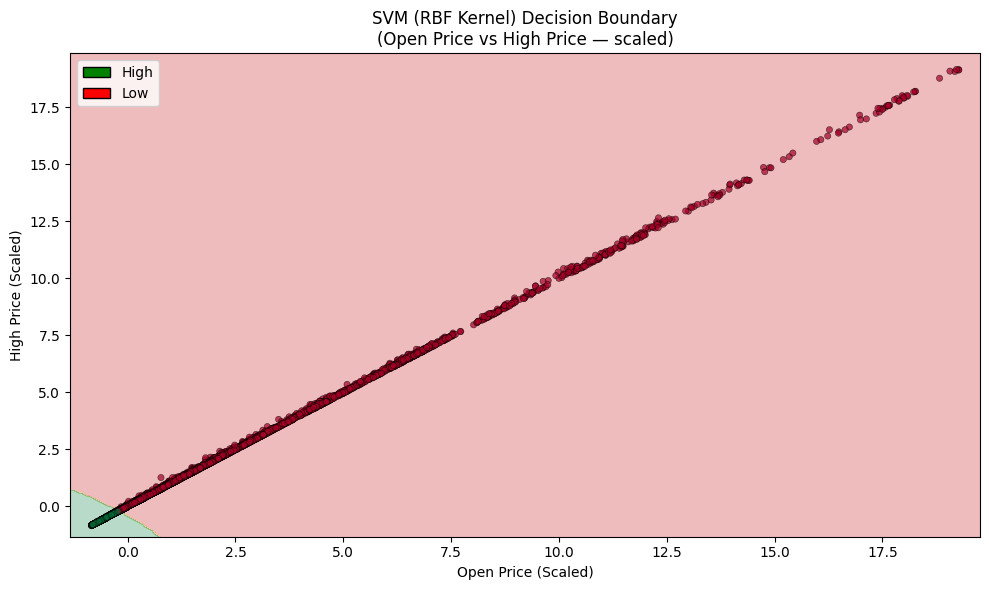

In [54]:
plt.figure(figsize=(10, 6))

plt.contourf(
    xx,
    yy,
    grid_encoded,
    alpha=0.3,
    cmap='RdYlGn'
)

y_vis_test_encoded = encoder.transform(y_vis_test)

scatter = plt.scatter(
    X_vis_test[:, 0],
    X_vis_test[:, 1],
    c=y_vis_test_encoded,
    cmap='RdYlGn',
    edgecolors='k',
    linewidths=0.4,
    s=20,
    alpha=0.7
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='k', label='High'),
    Patch(facecolor='red',   edgecolor='k', label='Low')
]
plt.legend(handles=legend_elements)

plt.title("SVM (RBF Kernel) Decision Boundary\n(Open Price vs High Price — scaled)")
plt.xlabel("Open Price (Scaled)")
plt.ylabel("High Price (Scaled)")

plt.tight_layout()
plt.show()